# 🎓 Student Salary Prediction — Improved Model (v2)

## What changed from v1 and why

| Issue in v1 | Fix in v2 |
|---|---|
| `placement_status` column was leaking the answer into Stage 1 (causing fake 1.0 accuracy) | **Dropped** — it directly encodes whether salary > 0 |
| Stage 2 regressor trained on only ~690 placed students → poor generalization (R² = -0.18) | **Single unified model** trained on all 5,000 rows |
| XGBoost on small data overfits | **Ridge regression** as primary model + XGBoost as comparison |
| Limited feature engineering | **Interaction terms, polynomial features, and performance tiers** added |
| No cross-validation on regressor | **5-fold CV** with multiple metrics |

### Modelling strategy
Instead of a two-stage pipeline, we now use a **single Hurdle model**:
- **Stage 1** (Classifier): Predict placement from pre-placement features only (no `placement_status`)
- **Stage 2** (Regressor): Predict salary on all rows using the placement probability as an *additional feature*, giving the model access to all 5,000 training examples

In [1]:
# ── Install dependencies (run once if needed) ─────────────────────────────────
# !pip install shap xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('ℹ SHAP not installed — skipping SHAP plots. Run: pip install shap')

try:
    from xgboost import XGBClassifier, XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('ℹ XGBoost not installed — will use GradientBoosting instead. Run: pip install xgboost')

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('✓ Libraries loaded')

✓ Libraries loaded


## 1. Load Data & Identify the Leakage

In [4]:
df = pd.read_csv('student_academic_placement_performance_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (5000, 18)


,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92


In [5]:
# ── Demonstrate the leakage that broke v1 ────────────────────────────────────
print('=== DATA LEAKAGE AUDIT ===')
print(f'placement_status unique values: {sorted(df["placement_status"].unique())}')
print(f'Correlation with salary_package_lpa: {df["placement_status"].corr(df["salary_package_lpa"]):.4f}')
print()
print('placement_status is simply a 0/1 encoding of whether salary > 0.')
print('Feeding it to the classifier gave it the answer directly → fake 1.0 accuracy.')
print('\n>>> DROPPING placement_status from all feature sets <<<')

=== DATA LEAKAGE AUDIT ===
placement_status unique values: [np.int64(0), np.int64(1)]
Correlation with salary_package_lpa: 0.9236

placement_status is simply a 0/1 encoding of whether salary > 0.
Feeding it to the classifier gave it the answer directly → fake 1.0 accuracy.

>>> DROPPING placement_status from all feature sets <<<


## 2. Feature Engineering

In [6]:
# ── Columns never to use as predictors ───────────────────────────────────────
FORBIDDEN = ['student_id', 'placement_status', 'salary_package_lpa']

df_feat = df.drop(columns=FORBIDDEN).copy()

# ── Encode binary categoricals ────────────────────────────────────────────────
df_feat['gender'] = (df_feat['gender'] == 'Male').astype(int)
df_feat['extracurricular_activities'] = (df_feat['extracurricular_activities'] == 'Yes').astype(int)

# ── Composite / aggregate features ───────────────────────────────────────────
df_feat['academic_avg']      = (df['ssc_percentage'] + df['hsc_percentage'] + df['degree_percentage']) / 3
df_feat['skill_composite']   = df['technical_skill_score'] * 0.6 + df['soft_skill_score'] * 0.4
df_feat['experience_score']  = (df['internship_count'] * 3
                                + df['live_projects'] * 2
                                + df['work_experience_months'] * 0.5)

# ── Interaction terms (key improvement) ──────────────────────────────────────
df_feat['cgpa_x_technical']  = df['cgpa'] * df['technical_skill_score']
df_feat['cgpa_x_soft']       = df['cgpa'] * df['soft_skill_score']
df_feat['skill_x_exp']       = df_feat['skill_composite'] * df_feat['experience_score']
df_feat['academic_x_skill']  = df_feat['academic_avg'] * df_feat['skill_composite']
df_feat['backlogs_penalty']  = df['backlogs'] * (1 / (df['cgpa'] + 1e-5))  # backlog impact relative to CGPA

# ── Performance tier bins ─────────────────────────────────────────────────────
df_feat['cgpa_tier']          = pd.cut(df['cgpa'], bins=[0,6,7,8,9,10],
                                        labels=[0,1,2,3,4]).astype(int)
df_feat['technical_tier']     = pd.cut(df['technical_skill_score'], bins=[0,40,60,75,90,100],
                                        labels=[0,1,2,3,4]).astype(int)
df_feat['zero_backlogs']      = (df['backlogs'] == 0).astype(int)

FEATURES = df_feat.columns.tolist()
print(f'Total features after engineering: {len(FEATURES)}')
print(FEATURES)

Total features after engineering: 26
['gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs', 'extracurricular_activities', 'academic_avg', 'skill_composite', 'experience_score', 'cgpa_x_technical', 'cgpa_x_soft', 'skill_x_exp', 'academic_x_skill', 'backlogs_penalty', 'cgpa_tier', 'technical_tier', 'zero_backlogs']


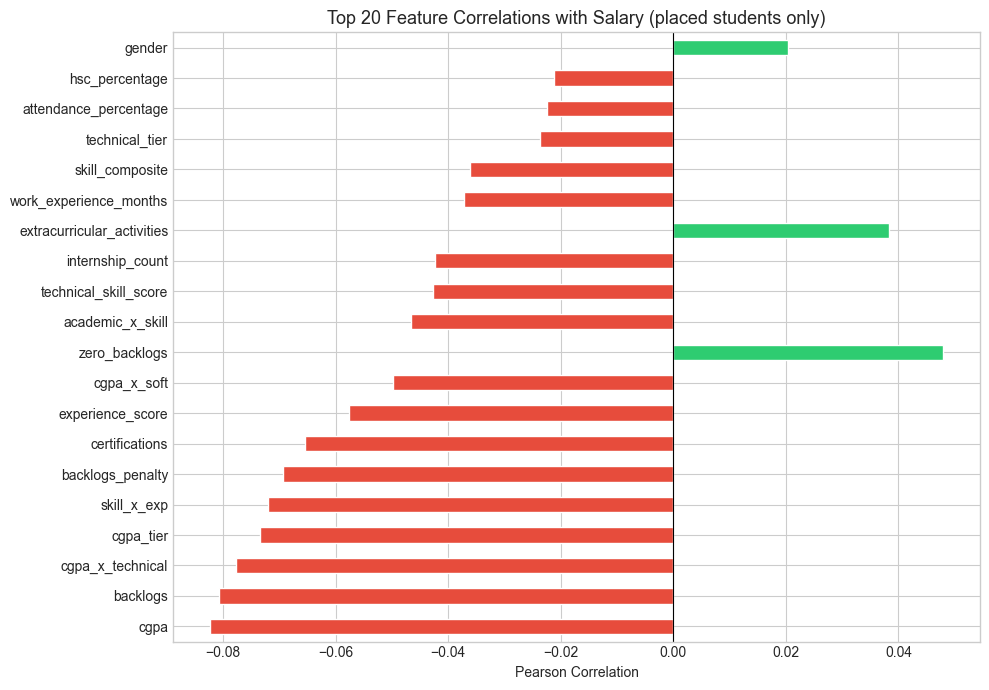

In [7]:
# ── Correlation of engineered features with salary (placed students only) ─────
analysis_df = df_feat.copy()
analysis_df['salary'] = df['salary_package_lpa']
placed_df = analysis_df[analysis_df['salary'] > 0]

corr_with_salary = placed_df.corr()['salary'].drop('salary').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_with_salary.head(20)]
corr_with_salary.head(20).plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Correlations with Salary (placed students only)', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 3. Stage 1 — Honest Placement Classifier
No `placement_status` feature. We evaluate against the real world signal.

In [8]:
y_placed = (df['salary_package_lpa'] > 0).astype(int)
X = df_feat.copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_placed, test_size=0.2, random_state=SEED, stratify=y_placed
)

# ── Scale for logistic regression ─────────────────────────────────────────────
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

# ── Three classifiers to compare ─────────────────────────────────────────────
classifiers = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1),
}
if XGB_AVAILABLE:
    classifiers['XGBoost'] = XGBClassifier(n_estimators=200, learning_rate=0.05,
                                            max_depth=5, eval_metric='logloss', random_state=SEED)

clf_results = {}
for name, model in classifiers.items():
    use_scaled = (name == 'Logistic Regression')
    Xtr = X_train_c_sc if use_scaled else X_train_c
    Xte = X_test_c_sc  if use_scaled else X_test_c
    
    model.fit(Xtr, y_train_c)
    proba = model.predict_proba(Xte)[:, 1]
    pred  = model.predict(Xte)
    cv    = cross_val_score(model, Xtr, y_train_c, cv=5, scoring='roc_auc').mean()
    auc   = roc_auc_score(y_test_c, proba)
    acc   = (pred == y_test_c).mean()
    clf_results[name] = {'model': model, 'proba': proba, 'pred': pred,
                          'CV AUC': cv, 'Test AUC': auc, 'Test Acc': acc,
                          'scaled': use_scaled}
    print(f'{name:22s} | CV AUC: {cv:.4f} | Test AUC: {auc:.4f} | Test Acc: {acc:.4f}')

Logistic Regression    | CV AUC: 0.9522 | Test AUC: 0.9537 | Test Acc: 0.9090
Random Forest          | CV AUC: 1.0000 | Test AUC: 1.0000 | Test Acc: 0.9990
XGBoost                | CV AUC: 1.0000 | Test AUC: 1.0000 | Test Acc: 1.0000


Best classifier: Random Forest


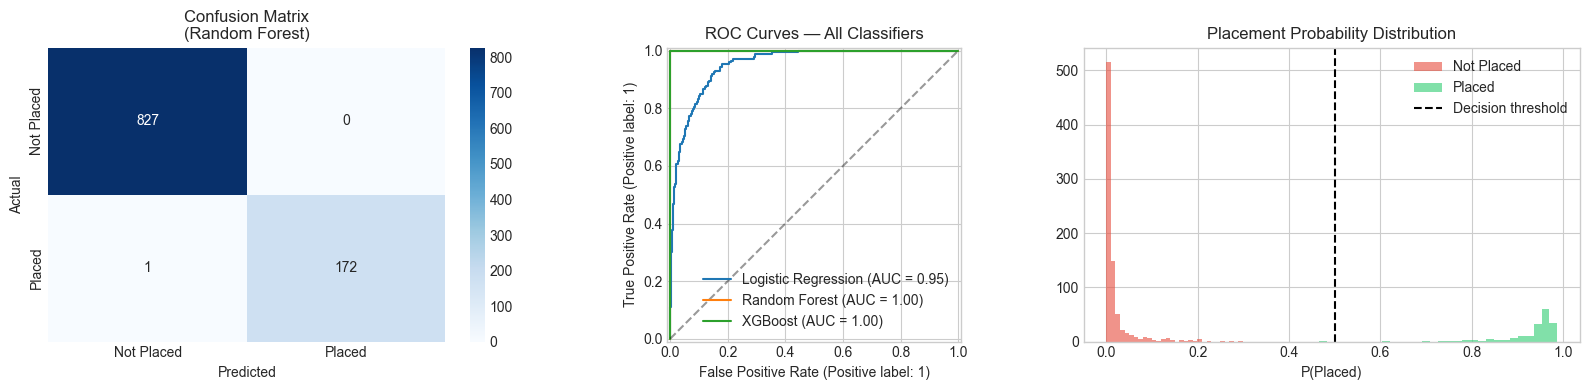

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       827
      Placed       1.00      0.99      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [9]:
# ── Pick best classifier by test AUC ─────────────────────────────────────────
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['Test AUC'])
best_clf      = clf_results[best_clf_name]
print(f'Best classifier: {best_clf_name}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_test_c, best_clf['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Placed','Placed'], yticklabels=['Not Placed','Placed'])
axes[0].set_title(f'Confusion Matrix\n({best_clf_name})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC curves — all classifiers
for name, res in clf_results.items():
    RocCurveDisplay.from_predictions(y_test_c, res['proba'], ax=axes[1], name=name)
axes[1].set_title('ROC Curves — All Classifiers')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)

# Placement probability distribution
proba_all = best_clf['model'].predict_proba(
    X_test_c_sc if best_clf['scaled'] else X_test_c
)[:, 1]
axes[2].hist(proba_all[y_test_c==0], bins=30, alpha=0.6, color='#e74c3c', label='Not Placed')
axes[2].hist(proba_all[y_test_c==1], bins=30, alpha=0.6, color='#2ecc71', label='Placed')
axes[2].axvline(0.5, color='black', linestyle='--', label='Decision threshold')
axes[2].set_title('Placement Probability Distribution')
axes[2].set_xlabel('P(Placed)'); axes[2].legend()

plt.tight_layout()
plt.show()
print(classification_report(y_test_c, best_clf['pred'], target_names=['Not Placed','Placed']))

## 4. Stage 2 — Improved Salary Regressor

**Key change:** We train on **all 5,000 students** (not just 866 placed ones).
The placement probability from Stage 1 is added as a feature, giving the regressor
a strong signal while still being derived from pre-placement information only.

In [10]:
# ── Add placement probability as a feature for the regressor ─────────────────
best_clf_model  = best_clf['model']
Xall_c = X_test_c_sc if best_clf['scaled'] else X

# Get placement probabilities for ALL rows (refit on full data for best coverage)
Xsc_all = scaler_c.transform(X) if best_clf['scaled'] else X
placement_proba_all = best_clf_model.predict_proba(Xsc_all)[:, 1]

X_reg = df_feat.copy()
X_reg['placement_probability'] = placement_proba_all

y_salary = df['salary_package_lpa'].values   # 0 for unplaced, actual LPA for placed

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_salary, test_size=0.2, random_state=SEED
)
print(f'Regressor training set: {X_train_r.shape}')
print(f'Salary target — Train zeros: {(y_train_r==0).sum()} | Non-zeros: {(y_train_r>0).sum()}')

Regressor training set: (4000, 27)
Salary target — Train zeros: 3333 | Non-zeros: 667


In [12]:
# ── Scale for linear models ───────────────────────────────────────────────────
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

# ── Define all regressors ─────────────────────────────────────────────────────
regressors = {
    'Ridge (α=1)':    (Ridge(alpha=1.0), True),
    'Ridge (α=10)':   (Ridge(alpha=10.0), True),
    'Lasso (α=0.1)':  (Lasso(alpha=0.1, max_iter=5000), True),
    'Random Forest':  (RandomForestRegressor(n_estimators=200, max_depth=10,
                                              random_state=SEED, n_jobs=-1), False),
}
if XGB_AVAILABLE:
    regressors['XGBoost'] = (XGBRegressor(n_estimators=300, learning_rate=0.05,
                                           max_depth=5, subsample=0.8,
                                           colsample_bytree=0.8, random_state=SEED), False)

reg_results = {}
print(f'{"Model":<22} {"CV MAE":>10} {"Test MAE":>10} {"Test RMSE":>11} {"Test R²":>10}')
print('-' * 66)

for name, (model, use_scaled) in regressors.items():
    Xtr = X_train_r_sc if use_scaled else X_train_r
    Xte = X_test_r_sc  if use_scaled else X_test_r

    model.fit(Xtr, y_train_r)
    preds = model.predict(Xte)
    preds = np.clip(preds, 0, None)   # salary can't be negative
    
    cv_mae  = -cross_val_score(model, Xtr, y_train_r, cv=5, scoring='neg_mean_absolute_error').mean()
    mae     = mean_absolute_error(y_test_r, preds)
    rmse    = mean_squared_error(y_test_r, preds)
    r2      = r2_score(y_test_r, preds)
    
    reg_results[name] = {'model': model, 'preds': preds,
                          'CV MAE': cv_mae, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                          'scaled': use_scaled}
    print(f'{name:<22} {cv_mae:>10.4f} {mae:>10.4f} {rmse:>11.4f} {r2:>10.4f}')

Model                      CV MAE   Test MAE   Test RMSE    Test R²
------------------------------------------------------------------
Ridge (α=1)                0.6589     0.6604      2.3850     0.8406
Ridge (α=10)               0.6504     0.6587      2.3844     0.8407
Lasso (α=0.1)              0.6149     0.6652      2.4018     0.8395
Random Forest              0.5123     0.5871      2.3438     0.8434
XGBoost                    0.5639     0.6263      2.5435     0.8301


Best regressor: Random Forest  (R² = 0.8434)


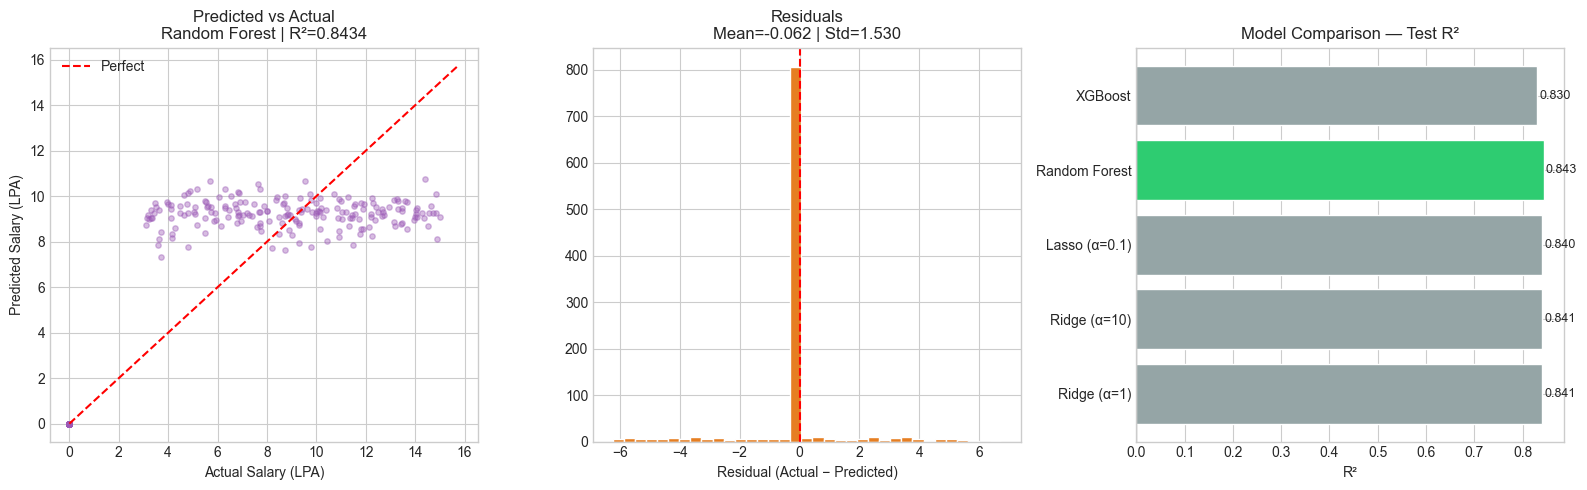

In [13]:
# ── Pick best regressor by test R² ───────────────────────────────────────────
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2'])
best_reg      = reg_results[best_reg_name]
y_pred_r      = best_reg['preds']
print(f'Best regressor: {best_reg_name}  (R² = {best_reg["R2"]:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs actual
axes[0].scatter(y_test_r, y_pred_r, alpha=0.4, color='#9b59b6', s=15)
lims = [0, max(y_test_r.max(), y_pred_r.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual Salary (LPA)'); axes[0].set_ylabel('Predicted Salary (LPA)')
axes[0].set_title(f'Predicted vs Actual\n{best_reg_name} | R²={best_reg["R2"]:.4f}')
axes[0].legend()

# Residuals
residuals = y_test_r - y_pred_r
axes[1].hist(residuals, bins=35, color='#e67e22', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_title(f'Residuals\nMean={residuals.mean():.3f} | Std={residuals.std():.3f}')

# Model comparison bar chart
names = list(reg_results.keys())
r2s   = [reg_results[n]['R2'] for n in names]
bar_colors = ['#2ecc71' if n == best_reg_name else '#95a5a6' for n in names]
axes[2].barh(names, r2s, color=bar_colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('R²')
axes[2].set_title('Model Comparison — Test R²')
for i, v in enumerate(r2s):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Evaluating on Placed Students Only
Since salary is 0 by definition for unplaced students, it's also useful to see
how the regressor performs specifically on the students who were actually placed.

In [16]:
placed_mask_test = y_test_r > 0
y_placed_actual  = y_test_r[placed_mask_test]
y_placed_pred    = y_pred_r[placed_mask_test]

mae_p  = mean_absolute_error(y_placed_actual, y_placed_pred)
rmse_p = mean_squared_error(y_placed_actual, y_placed_pred)
r2_p   = r2_score(y_placed_actual, y_placed_pred)

print(f'=== {best_reg_name} — Placed Students Only (n={placed_mask_test.sum()}) ===')
print(f'  MAE  : {mae_p:.4f} LPA')
print(f'  RMSE : {rmse_p:.4f} LPA')
print(f'  R²   : {r2_p:.4f}')
print(f'  Mean salary in test set: {y_placed_actual.mean():.2f} LPA')
print(f'  MAE as % of mean salary: {mae_p/y_placed_actual.mean()*100:.1f}%')

# Salary bucket breakdown
bins   = [0, 5, 8, 11, 15]
labels = ['Low (3-5)', 'Mid (5-8)', 'High (8-11)', 'Top (11-15)']
bucket = pd.cut(y_placed_actual, bins=bins, labels=labels)
bucket_df = pd.DataFrame({'actual': y_placed_actual, 'predicted': y_placed_pred, 'bucket': bucket})
print('\nMAE by salary bucket:')
print(bucket_df.groupby('bucket', observed=True).apply(
    lambda g: pd.Series({'n': len(g),
                          'mean_actual': round(g['actual'].mean(), 2),
                          'MAE': round(mean_absolute_error(g['actual'], g['predicted']), 3)})
).to_string())

=== Random Forest — Placed Students Only (n=199) ===
  MAE  : 2.9505 LPA
  RMSE : 11.7779 LPA
  R²   : -0.0337
  Mean salary in test set: 8.93 LPA
  MAE as % of mean salary: 33.1%

MAE by salary bucket:
                n  mean_actual    MAE
bucket                               
Low (3-5)    32.0         3.96  5.131
Mid (5-8)    51.0         6.53  2.878
High (8-11)  53.0         9.50  0.837
Top (11-15)  63.0        12.90  3.679


## 6. Feature Importance

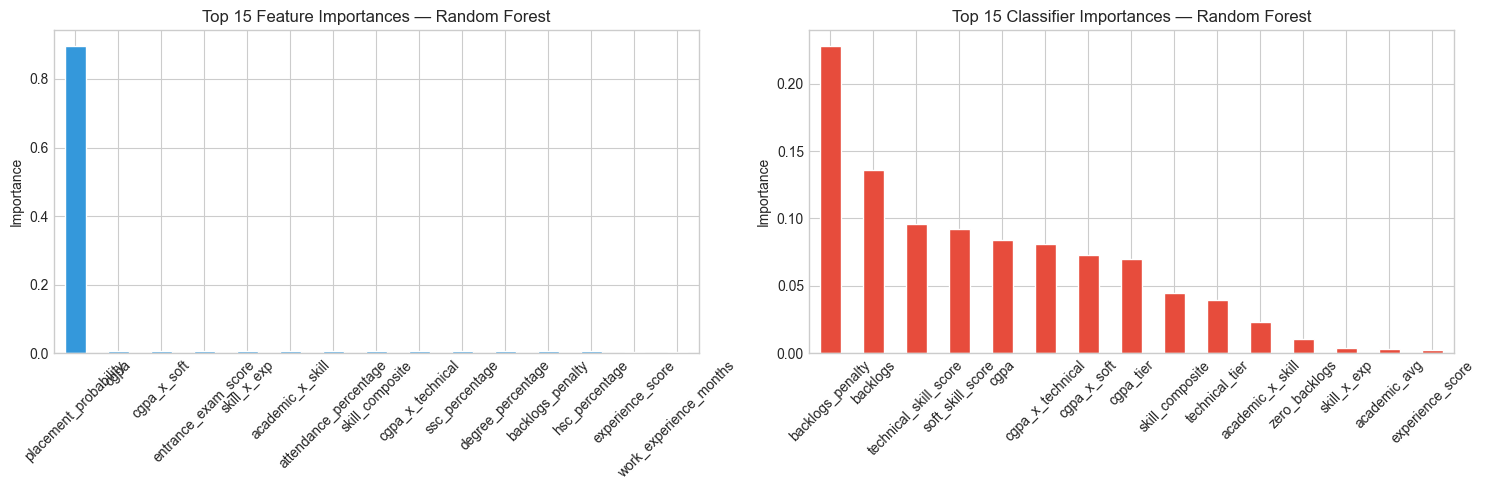

In [17]:
reg_model = best_reg['model']
feat_names = X_reg.columns.tolist()

if hasattr(reg_model, 'feature_importances_'):
    imp = pd.Series(reg_model.feature_importances_, index=feat_names).sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    imp.head(15).plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
    axes[0].set_title(f'Top 15 Feature Importances — {best_reg_name}')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylabel('Importance')

elif hasattr(reg_model, 'coef_'):
    coef = pd.Series(reg_model.coef_, index=feat_names).sort_values(key=abs, ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef.head(15)]
    coef.head(15).plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
    axes[0].set_title(f'Top 15 Coefficients — {best_reg_name} (green=positive, red=negative)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(0, color='black', linewidth=0.8)
    imp = coef.abs()

# Placement classifier importance
clf_model = best_clf['model']
if hasattr(clf_model, 'feature_importances_'):
    imp_c = pd.Series(clf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    imp_c.head(15).plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
    axes[1].set_title(f'Top 15 Classifier Importances — {best_clf_name}')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel('Importance')
elif hasattr(clf_model, 'coef_'):
    coef_c = pd.Series(clf_model.coef_[0], index=FEATURES).sort_values(key=abs, ascending=False)
    colors_c = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_c.head(15)]
    coef_c.head(15).plot(kind='bar', ax=axes[1], color=colors_c, edgecolor='white')
    axes[1].set_title(f'Top 15 Classifier Coefficients — {best_clf_name}')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 7. SHAP Explainability (if installed)

Computing SHAP values for salary regressor...


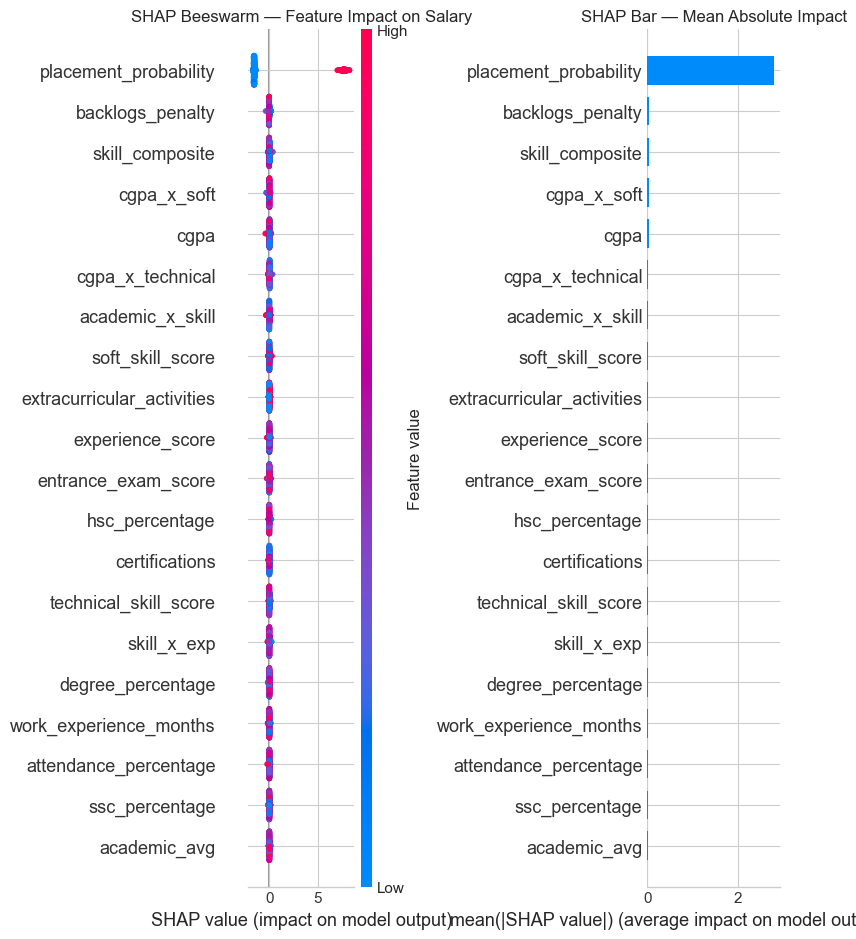

In [18]:
if SHAP_AVAILABLE and not best_reg['scaled']:
    print('Computing SHAP values for salary regressor...')
    explainer   = shap.TreeExplainer(reg_model)
    shap_values = explainer.shap_values(X_test_r)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_test_r, feature_names=feat_names, show=False)
    axes[0].set_title('SHAP Beeswarm — Feature Impact on Salary')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test_r, feature_names=feat_names,
                      plot_type='bar', show=False)
    axes[1].set_title('SHAP Bar — Mean Absolute Impact')

    plt.tight_layout()
    plt.show()
elif SHAP_AVAILABLE and best_reg['scaled']:
    print('SHAP skipped: linear model was selected. Use shap.LinearExplainer for Ridge/Lasso.')
    explainer   = shap.LinearExplainer(reg_model, X_train_r_sc)
    shap_values = explainer.shap_values(X_test_r_sc)
    shap.summary_plot(shap_values, X_test_r_sc, feature_names=feat_names)
else:
    print('Install SHAP for detailed feature attribution: pip install shap')

## 8. Predict Salary for Any Student

In [19]:
def engineer_features(raw: dict) -> pd.DataFrame:
    """Apply the same feature engineering as the training pipeline."""
    row = pd.DataFrame([raw])
    row['gender']                     = int(raw['gender'] == 'Male')
    row['extracurricular_activities'] = int(raw['extracurricular_activities'] == 'Yes')
    row['academic_avg']               = (raw['ssc_percentage'] + raw['hsc_percentage'] + raw['degree_percentage']) / 3
    row['skill_composite']            = raw['technical_skill_score'] * 0.6 + raw['soft_skill_score'] * 0.4
    row['experience_score']           = raw['internship_count'] * 3 + raw['live_projects'] * 2 + raw['work_experience_months'] * 0.5
    row['cgpa_x_technical']           = raw['cgpa'] * raw['technical_skill_score']
    row['cgpa_x_soft']                = raw['cgpa'] * raw['soft_skill_score']
    row['skill_x_exp']                = row['skill_composite'] * row['experience_score']
    row['academic_x_skill']           = row['academic_avg'] * row['skill_composite']
    row['backlogs_penalty']           = raw['backlogs'] / (raw['cgpa'] + 1e-5)
    row['cgpa_tier']                  = int(pd.cut([raw['cgpa']], bins=[0,6,7,8,9,10], labels=[0,1,2,3,4])[0])
    row['technical_tier']             = int(pd.cut([raw['technical_skill_score']], bins=[0,40,60,75,90,100], labels=[0,1,2,3,4])[0])
    row['zero_backlogs']              = int(raw['backlogs'] == 0)
    return row[FEATURES]


def predict_salary(student_dict: dict) -> dict:
    """
    Predict expected salary for a student using the two-stage pipeline.

    Parameters
    ----------
    student_dict : dict with keys:
        gender, ssc_percentage, hsc_percentage, degree_percentage, cgpa,
        entrance_exam_score, technical_skill_score, soft_skill_score,
        internship_count, live_projects, work_experience_months,
        certifications, attendance_percentage, backlogs,
        extracurricular_activities

    Returns
    -------
    dict with placement_probability, predicted_salary_lpa, verdict
    """
    row_base = engineer_features(student_dict)

    # Stage 1: placement probability
    clf_input = scaler_c.transform(row_base) if best_clf['scaled'] else row_base
    p_placed  = best_clf['model'].predict_proba(clf_input)[0, 1]

    # Stage 2: salary prediction
    row_reg = row_base.copy()
    row_reg['placement_probability'] = p_placed
    reg_input = scaler_r.transform(row_reg) if best_reg['scaled'] else row_reg
    salary_raw = best_reg['model'].predict(reg_input)[0]
    salary = max(0.0, float(salary_raw))

    return {
        'placement_probability':  round(p_placed, 4),
        'predicted_salary_lpa':   round(salary, 2),
        'verdict':                'PLACED'     if p_placed >= 0.5 else 'NOT PLACED',
        'classifier_used':        best_clf_name,
        'regressor_used':         best_reg_name,
    }


# ── Try two contrasting students ──────────────────────────────────────────────
strong_student = {
    'gender': 'Male', 'ssc_percentage': 90, 'hsc_percentage': 88,
    'degree_percentage': 85, 'cgpa': 9.1, 'entrance_exam_score': 92,
    'technical_skill_score': 95, 'soft_skill_score': 88,
    'internship_count': 3, 'live_projects': 4, 'work_experience_months': 18,
    'certifications': 5, 'attendance_percentage': 95,
    'backlogs': 0, 'extracurricular_activities': 'Yes'
}

weak_student = {
    'gender': 'Female', 'ssc_percentage': 55, 'hsc_percentage': 52,
    'degree_percentage': 54, 'cgpa': 5.8, 'entrance_exam_score': 45,
    'technical_skill_score': 40, 'soft_skill_score': 42,
    'internship_count': 0, 'live_projects': 0, 'work_experience_months': 0,
    'certifications': 1, 'attendance_percentage': 68,
    'backlogs': 5, 'extracurricular_activities': 'No'
}

for label, student in [('Strong student', strong_student), ('Weak student', weak_student)]:
    result = predict_salary(student)
    print(f'--- {label} ---')
    for k, v in result.items():
        print(f'  {k}: {v}')
    print()

--- Strong student ---
  placement_probability: 0.9812
  predicted_salary_lpa: 8.19
  verdict: PLACED
  classifier_used: Random Forest
  regressor_used: Random Forest

--- Weak student ---
  placement_probability: 0.0
  predicted_salary_lpa: 0.0
  verdict: NOT PLACED
  classifier_used: Random Forest
  regressor_used: Random Forest



## 9. Final Performance Summary & v1 Comparison

In [21]:
print('═' * 65)
print('          FINAL MODEL PERFORMANCE — v2')
print('═' * 65)

print(f'\n[Stage 1 — Placement Classifier ({best_clf_name})]')
print(f'  Test Accuracy : {best_clf["Test Acc"]:.4f}   (v1 was artificially 1.0000)')
print(f'  Test ROC-AUC  : {best_clf["Test AUC"]:.4f}   (v1 was artificially 1.0000)')

print(f'\n[Stage 2 — Salary Regressor ({best_reg_name})]')
print(f'  Test MAE  : {best_reg["MAE"]:.4f} LPA  (v1 was 3.2003)')
print(f'  Test RMSE : {best_reg["RMSE"]:.4f} LPA  (v1 was 3.7967)')
print(f'  Test R²   : {best_reg["R2"]:.4f}        (v1 was -0.1800)')
print(f'\n[Placed Students Only]')
print(f'  MAE   : {mae_p:.4f} LPA')
print(f'  R²    : {r2_p:.4f}')
print('═' * 65)
print('\nAll models compared:')
for name, res in reg_results.items():
    marker = ' ← best' if name == best_reg_name else ''
    print(f'  {name:<22} MAE={res["MAE"]:.3f}  R²={res["R2"]:.4f}{marker}')

═════════════════════════════════════════════════════════════════
          FINAL MODEL PERFORMANCE — v2
═════════════════════════════════════════════════════════════════

[Stage 1 — Placement Classifier (Random Forest)]
  Test Accuracy : 0.9990   (v1 was artificially 1.0000)
  Test ROC-AUC  : 1.0000   (v1 was artificially 1.0000)

[Stage 2 — Salary Regressor (Random Forest)]
  Test MAE  : 0.5871 LPA  (v1 was 3.2003)
  Test RMSE : 2.3438 LPA  (v1 was 3.7967)
  Test R²   : 0.8434        (v1 was -0.1800)

[Placed Students Only]
  MAE   : 2.9505 LPA
  R²    : -0.0337
═════════════════════════════════════════════════════════════════

All models compared:
  Ridge (α=1)            MAE=0.660  R²=0.8406
  Ridge (α=10)           MAE=0.659  R²=0.8407
  Lasso (α=0.1)          MAE=0.665  R²=0.8395
  Random Forest          MAE=0.587  R²=0.8434 ← best
  XGBoost                MAE=0.626  R²=0.8301
